# Retrieval Evaluation v3 — Discriminative Retrieval Benchmark

## Research objective

v3 addresses the main limitation identified in v1/v2: when all 299 candidates are treated equally, very common labels make a large fraction of pairs relevant. This produces an overly easy retrieval task and a high random baseline.

v3 therefore adds a **controlled query–candidate benchmark** while preserving the original evaluation as an ablation.

### Evaluation layers

1. **Original all-pairs Jaccard** — direct v1 reproduction.
2. **IDF-weighted Jaccard** — reduces the effect of ubiquitous labels.
3. **Controlled hard-negative benchmark** — tests whether a retriever can distinguish:
   - positives with strong rare-label overlap,
   - hard negatives sharing common labels but not the rare-label profile,
   - random negatives.
4. Baselines:
   - Random
   - TF-IDF
   - BM25
   - SBERT
5. Metrics:
   - Hit@1 / Hit@3 / Hit@5 / Hit@10
   - Precision@K
   - Recall@K
   - MRR
   - MAP
   - NDCG@K
   - paired bootstrap 95% CI
   - paired permutation test

**Important:** v3 does not tune labels or thresholds to make SBERT win. All sampling rules are fixed before retrieval scores are evaluated.


In [1]:
!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib openpyxl rank_bm25 scipy



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\DUNG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os, math, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from rank_bm25 import BM25Okapi

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

GOLD_XLSX_PATH = "verA_kappa.xlsx"
GOLD_SHEET = "Worksheet"

OUTPUT_XLSX = "retrieval_results_v3.xlsx"
PLOT_PATH = "retrieval_v3_benchmark.png"

LABELS = [
    "fnb_street", "fnb_fine", "fnb_cafe", "fnb_healthy",
    "tour_cultural", "tour_resort", "tour_adventure",
    "tour_food", "tour_festival"
]
GOLD_COLS = [f"gold_{x}" for x in LABELS]

K_LIST = [1, 3, 5, 10]
BOOTSTRAP_N = 2000
N_POS = 10
N_HARD_NEG = 20
N_RANDOM_NEG = 20

# Fixed rules — do not tune after seeing retrieval results.
RARE_LABEL_RATE_MAX = 0.30
POS_WEIGHTED_JACCARD_MIN = 0.50
HARD_NEG_COMMON_JACCARD_MIN = 0.50
HARD_NEG_WEIGHTED_JACCARD_MAX = 0.25

print("Fixed benchmark configuration")
print("N_POS =", N_POS)
print("N_HARD_NEG =", N_HARD_NEG)
print("N_RANDOM_NEG =", N_RANDOM_NEG)
print("RARE_LABEL_RATE_MAX =", RARE_LABEL_RATE_MAX)


Fixed benchmark configuration
N_POS = 10
N_HARD_NEG = 20
N_RANDOM_NEG = 20
RARE_LABEL_RATE_MAX = 0.3


## 1. Load and validate the gold personas

Missing labels remain missing. They are never silently converted to negative labels.


In [3]:
df_raw = pd.read_excel(GOLD_XLSX_PATH, sheet_name=GOLD_SHEET)

required = ["persona_id", "merged_text"] + GOLD_COLS
missing_cols = [c for c in required if c not in df_raw.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

gold = df_raw[required].copy()

for c in GOLD_COLS:
    gold[c] = pd.to_numeric(gold[c], errors="coerce")
    gold.loc[~gold[c].isin([0, 1]), c] = np.nan

gold["merged_text"] = gold["merged_text"].fillna("").astype(str)
gold["persona_id"] = pd.to_numeric(gold["persona_id"], errors="coerce").astype("Int64")

N = len(gold)
persona_ids = gold["persona_id"].astype(int).tolist()
texts = gold["merged_text"].tolist()

print("N personas:", N)
print("\nMissing labels:")
print(gold[GOLD_COLS].isna().sum())

prev = []
for lb, c in zip(LABELS, GOLD_COLS):
    observed = gold[c].dropna()
    prev.append({
        "label": lb,
        "n_observed": len(observed),
        "n_positive": int(observed.sum()),
        "positive_rate": float(observed.mean()) if len(observed) else np.nan
    })
prevalence_df = pd.DataFrame(prev)
display(prevalence_df)


N personas: 300

Missing labels:
gold_fnb_street        0
gold_fnb_fine          0
gold_fnb_cafe          0
gold_fnb_healthy       0
gold_tour_cultural     0
gold_tour_resort       0
gold_tour_adventure    0
gold_tour_food         1
gold_tour_festival     0
dtype: int64


,label,n_observed,n_positive,positive_rate
0,fnb_street,300,298,0.993333
1,fnb_fine,300,20,0.066667
2,fnb_cafe,300,44,0.146667
3,fnb_healthy,300,88,0.293333
4,tour_cultural,300,239,0.796667
5,tour_resort,300,35,0.116667
6,tour_adventure,300,55,0.183333
7,tour_food,299,235,0.785953
8,tour_festival,300,234,0.780000


## 2. Build label weights

IDF weights are calculated once from the full gold set.

A label is considered **rare** if its observed positive rate is ≤ 30%. This threshold is fixed as a benchmark design rule, not optimized against retrieval results.


In [4]:
Y = gold[GOLD_COLS].to_numpy(dtype=float)

df_label = np.nansum(Y, axis=0)
idf_weights = np.log((N + 1) / (df_label + 1)) + 1.0
positive_rates = df_label / N

rare_mask = positive_rates <= RARE_LABEL_RATE_MAX
rare_labels = [LABELS[i] for i, x in enumerate(rare_mask) if x]

weight_df = pd.DataFrame({
    "label": LABELS,
    "positive_count": df_label.astype(int),
    "positive_rate": positive_rates,
    "idf_weight": idf_weights,
    "is_rare": rare_mask
})

display(weight_df)
print("Rare labels:", rare_labels)


,label,positive_count,positive_rate,idf_weight,is_rare
0,fnb_street,298,0.993333,1.006667,False
1,fnb_fine,20,0.066667,3.662588,True
2,fnb_cafe,44,0.146667,2.900448,True
3,fnb_healthy,88,0.293333,2.218474,True
4,tour_cultural,239,0.796667,1.226471,False
5,tour_resort,35,0.116667,3.123591,True
6,tour_adventure,55,0.183333,2.681759,True
7,tour_food,235,0.783333,1.243278,False
8,tour_festival,234,0.780000,1.247525,False


Rare labels: ['fnb_fine', 'fnb_cafe', 'fnb_healthy', 'tour_resort', 'tour_adventure']


## 3. Pairwise similarity functions

Two forms are retained:

- Standard Jaccard: reproduces the original methodology.
- IDF-weighted Jaccard: gives rare labels greater discriminative weight.

Missing labels are excluded pairwise.


In [5]:
def pair_similarity(i, j):
    yi, yj = Y[i], Y[j]
    valid = ~np.isnan(yi) & ~np.isnan(yj)

    if not np.any(valid):
        return np.nan, np.nan, np.nan, 0

    a = yi[valid] == 1
    b = yj[valid] == 1

    inter = a & b
    union = a | b

    jaccard = inter.sum() / union.sum() if union.sum() else 0.0

    w = idf_weights[valid]
    denom = w[union].sum()
    numer = w[inter].sum()
    weighted = numer / denom if denom > 0 else 0.0

    rare_valid = rare_mask[valid]
    rare_inter = inter & rare_valid
    rare_union = union & rare_valid
    rare_jaccard = (
        rare_inter.sum() / rare_union.sum()
        if rare_union.sum() else 0.0
    )

    return float(jaccard), float(weighted), float(rare_jaccard), int(valid.sum())


J = np.zeros((N, N))
JW = np.zeros((N, N))
RJ = np.zeros((N, N))
VALID = np.zeros((N, N), dtype=int)

for i in range(N):
    for j in range(i + 1, N):
        j0, jw, rj, nv = pair_similarity(i, j)
        J[i, j] = J[j, i] = j0
        JW[i, j] = JW[j, i] = jw
        RJ[i, j] = RJ[j, i] = rj
        VALID[i, j] = VALID[j, i] = nv

np.fill_diagonal(J, 0)
np.fill_diagonal(JW, 0)
np.fill_diagonal(RJ, 0)
np.fill_diagonal(VALID, 0)

print("Pairwise matrices:", J.shape)


Pairwise matrices: (300, 300)


## 4. Encode and prepare retrieval methods

All methods operate on the same 300 personas.

SBERT uses the same model as v1/v2 for comparability.


In [6]:
print("Encoding SBERT...")
sbert = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
emb = sbert.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)
sbert_sim = cosine_similarity(emb)
np.fill_diagonal(sbert_sim, -np.inf)

print("Building TF-IDF...")
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(texts)
tfidf_sim = cosine_similarity(X_tfidf)
np.fill_diagonal(tfidf_sim, -np.inf)

print("Building BM25...")
tokenized = [t.lower().split() for t in texts]
from rank_bm25 import BM25Okapi
bm25 = BM25Okapi(tokenized)

bm25_sim = np.zeros((N, N))
for i, q in enumerate(tokenized):
    bm25_sim[i] = bm25.get_scores(q)
np.fill_diagonal(bm25_sim, -np.inf)

print("Prepared:", ["Random", "TF-IDF", "BM25", "SBERT"])


Encoding SBERT...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Building TF-IDF...
Building BM25...
Prepared: ['Random', 'TF-IDF', 'BM25', 'SBERT']


## 5. Construct the controlled benchmark

For each query persona:

### Positive candidates
Candidates must satisfy:

- strong IDF-weighted overlap: `weighted Jaccard >= 0.50`
- at least one shared rare label

### Hard negatives
Candidates must satisfy:

- common-label overlap: standard Jaccard >= 0.50
- low discriminative overlap: weighted Jaccard <= 0.25
- no strong rare-label match

This deliberately creates candidates that look similar under common labels but differ in the more informative label profile.

### Random negatives
Randomly sampled from candidates that are neither positive nor hard-negative.

If a query cannot produce the requested number of candidates, the query is retained with the maximum available number. The notebook reports the final benchmark composition rather than silently inventing examples.


In [7]:
def candidate_sets(q):
    candidates = np.array([i for i in range(N) if i != q])

    positive = candidates[
        (JW[q, candidates] >= POS_WEIGHTED_JACCARD_MIN) &
        (RJ[q, candidates] > 0)
    ]

    hard = candidates[
        (J[q, candidates] >= HARD_NEG_COMMON_JACCARD_MIN) &
        (JW[q, candidates] <= HARD_NEG_WEIGHTED_JACCARD_MAX) &
        (RJ[q, candidates] == 0)
    ]

    used = set(positive.tolist()) | set(hard.tolist())
    random_pool = np.array([x for x in candidates if x not in used])

    return positive, hard, random_pool

benchmark_rows = []
query_records = []

for q in range(N):
    positive, hard, random_pool = candidate_sets(q)

    # Deterministic sampling; candidates are shuffled with a fixed seed.
    local_rng = np.random.default_rng(RANDOM_STATE + q)

    pos_take = min(N_POS, len(positive))
    hard_take = min(N_HARD_NEG, len(hard))
    rand_take = min(N_RANDOM_NEG, len(random_pool))

    if pos_take == 0:
        continue

    pos_sel = local_rng.choice(positive, size=pos_take, replace=False)
    hard_sel = local_rng.choice(hard, size=hard_take, replace=False) if hard_take else np.array([], dtype=int)
    rand_sel = local_rng.choice(random_pool, size=rand_take, replace=False) if rand_take else np.array([], dtype=int)

    candidates_selected = np.concatenate([pos_sel, hard_sel, rand_sel])

    for c in candidates_selected:
        category = (
            "positive" if c in set(pos_sel)
            else "hard_negative" if c in set(hard_sel)
            else "random_negative"
        )

        benchmark_rows.append({
            "query_index": q,
            "query_persona_id": persona_ids[q],
            "candidate_index": int(c),
            "candidate_persona_id": persona_ids[c],
            "category": category,
            "jaccard": J[q, c],
            "weighted_jaccard": JW[q, c],
            "rare_jaccard": RJ[q, c],
            "valid_labels": VALID[q, c]
        })

    query_records.append({
        "query_index": q,
        "persona_id": persona_ids[q],
        "n_positive": pos_take,
        "n_hard_negative": hard_take,
        "n_random_negative": rand_take,
        "positive_available": len(positive),
        "hard_negative_available": len(hard),
        "random_negative_available": len(random_pool)
    })

benchmark_df = pd.DataFrame(benchmark_rows)
query_sampling_df = pd.DataFrame(query_records)

print("Queries with at least one positive:", len(query_sampling_df))
display(query_sampling_df[["n_positive","n_hard_negative","n_random_negative"]].describe())
print("\nBenchmark composition:")
display(benchmark_df["category"].value_counts())


Queries with at least one positive: 184


,n_positive,n_hard_negative,n_random_negative
count,184.000000,184.0,184.0
mean,9.983696,0.0,20.0
std,0.221163,0.0,0.0
min,7.000000,0.0,20.0
25%,10.000000,0.0,20.0
50%,10.000000,0.0,20.0
75%,10.000000,0.0,20.0
max,10.000000,0.0,20.0



Benchmark composition:


category
random_negative    3680
positive           1837
Name: count, dtype: int64

## 6. Validate the benchmark before scoring retrieval

This is a critical anti-leakage / anti-tuning check.

The benchmark is inspected independently of retrieval scores. We verify that positives have substantially higher label similarity than hard negatives and random negatives.


In [8]:
benchmark_summary = (
    benchmark_df
    .groupby("category")[["jaccard","weighted_jaccard","rare_jaccard","valid_labels"]]
    .agg(["mean","median","std"])
)

display(benchmark_summary)

print("\nMean weighted Jaccard by category:")
display(
    benchmark_df.groupby("category")["weighted_jaccard"]
    .mean()
    .sort_values(ascending=False)
)


jaccard                     weighted_jaccard            \
                     mean    median       std             mean    median   
category                                                                   
positive         0.731987  0.714286  0.143941         0.713333  0.675515   
random_negative  0.495336  0.500000  0.171008         0.363117  0.355331   

                          rare_jaccard                     valid_labels  \
                      std         mean    median       std         mean   
category                                                                  
positive         0.149372     0.741517  0.666667  0.258026     9.000000   
random_negative  0.149037     0.040874  0.000000  0.141088     8.996739   

                                  
                median       std  
category                          
positive           9.0  0.000000  
random_negative    9.0  0.057019


Mean weighted Jaccard by category:


category
positive           0.713333
random_negative    0.363117
Name: weighted_jaccard, dtype: float64

## 7. Evaluate retrieval on the controlled candidate set

The key ranking task is:

> For each query, rank a fixed candidate pool and retrieve the positive candidates.

Hard negatives are deliberately included in the pool. This makes the task substantially more discriminative than ranking against every persona.


In [9]:
METHOD_SCORES = {
    "TF-IDF": tfidf_sim,
    "BM25": bm25_sim,
    "SBERT": sbert_sim
}

def rank_candidates(scores, q, candidates):
    vals = scores[q, candidates]
    order = np.argsort(-vals)
    return candidates[order]

def controlled_query_metrics(scores, q, candidates, positive_set, k_list=K_LIST):
    ranked = rank_candidates(scores, q, candidates)
    positive_set = set(positive_set)

    total_pos = len(positive_set)
    row = {
        "query_index": q,
        "persona_id": persona_ids[q],
        "n_candidates": len(candidates),
        "n_positive": total_pos
    }

    for k in k_list:
        top = ranked[:k]
        hits = np.array([1 if x in positive_set else 0 for x in top])
        n_hits = int(hits.sum())

        row[f"Hit@{k}"] = 1.0 if n_hits > 0 else 0.0
        row[f"P@{k}"] = n_hits / k
        row[f"Recall@{k}"] = n_hits / total_pos if total_pos else np.nan

        dcg = np.sum(hits / np.log2(np.arange(2, len(hits) + 2)))
        ideal_hits = np.ones(min(k, total_pos))
        idcg = np.sum(ideal_hits / np.log2(np.arange(2, len(ideal_hits) + 2)))
        row[f"NDCG@{k}"] = dcg / idcg if idcg > 0 else np.nan

    # AP and RR
    hits_all = np.array([1 if x in positive_set else 0 for x in ranked])
    hit_positions = np.where(hits_all == 1)[0]

    if total_pos:
        precisions = []
        hit_count = 0
        for rank, hit in enumerate(hits_all, start=1):
            if hit:
                hit_count += 1
                precisions.append(hit_count / rank)
        row["AP"] = np.mean(precisions) if precisions else 0.0
        row["RR"] = 1.0 / (hit_positions[0] + 1) if len(hit_positions) else 0.0
    else:
        row["AP"] = np.nan
        row["RR"] = np.nan

    # Hard-negative first position
    hard_set = set(
        benchmark_df[
            (benchmark_df["query_index"] == q) &
            (benchmark_df["category"] == "hard_negative")
        ]["candidate_index"].tolist()
    )
    hard_positions = [idx for idx, x in enumerate(ranked) if x in hard_set]
    row["first_hard_negative_rank"] = (min(hard_positions) + 1) if hard_positions else np.nan

    return row

controlled_results = []
controlled_per_query = {}

for method, scores in METHOD_SCORES.items():
    method_rows = []

    for q in query_sampling_df["query_index"].tolist():
        qdf = benchmark_df[benchmark_df["query_index"] == q]
        candidates = qdf["candidate_index"].to_numpy(dtype=int)
        positive_set = set(qdf[qdf["category"] == "positive"]["candidate_index"].tolist())

        row = controlled_query_metrics(scores, q, candidates, positive_set)
        row["method"] = method
        method_rows.append(row)

    pq = pd.DataFrame(method_rows)
    controlled_per_query[method] = pq

    summary = {
        "method": method,
        "n_queries": len(pq),
        **{
            m: pq[m].mean()
            for m in [
                "Hit@1","Hit@3","Hit@5","Hit@10",
                "P@1","P@3","P@5","P@10",
                "Recall@5","Recall@10",
                "NDCG@5","NDCG@10",
                "AP","RR",
                "first_hard_negative_rank"
            ]
        }
    }
    controlled_results.append(summary)

controlled_summary = pd.DataFrame(controlled_results)
display(controlled_summary)


,method,n_queries,Hit@1,Hit@3,Hit@5,Hit@10,P@1,P@3,P@5,P@10,Recall@5,Recall@10,NDCG@5,NDCG@10,AP,RR,first_hard_negative_rank
0,TF-IDF,184,0.418478,0.766304,0.934783,1.00000,0.418478,0.391304,0.364130,0.355435,0.182298,0.356134,0.376957,0.366874,0.425415,0.625047,NaN
1,BM25,184,0.375000,0.809783,0.918478,0.98913,0.375000,0.382246,0.373913,0.349457,0.187422,0.350155,0.375522,0.357974,0.421513,0.601525,NaN
2,SBERT,184,0.380435,0.771739,0.940217,1.00000,0.380435,0.362319,0.370652,0.355978,0.185559,0.356910,0.370807,0.360934,0.424746,0.602096,NaN


## 8. Random baseline for the controlled benchmark

Random is evaluated by repeatedly shuffling the same candidate pool. This avoids using a theoretical prevalence-only baseline for a ranking task with fixed positives and hard negatives.


In [10]:
RANDOM_REPEATS = 200

random_query_metrics = []

for q in query_sampling_df["query_index"].tolist():
    qdf = benchmark_df[benchmark_df["query_index"] == q]
    candidates = qdf["candidate_index"].to_numpy(dtype=int)
    positive_set = set(qdf[qdf["category"] == "positive"]["candidate_index"].tolist())

    local_rng = np.random.default_rng(RANDOM_STATE + 10000 + q)

    for rep in range(RANDOM_REPEATS):
        shuffled = candidates.copy()
        local_rng.shuffle(shuffled)

        # Build a temporary score row by assigning descending scores according to shuffle.
        temp_scores = np.full((1, len(candidates)), 0.0)
        rank_map = {c: len(candidates) - r for r, c in enumerate(shuffled)}
        ranked = np.array(sorted(candidates, key=lambda x: rank_map[x], reverse=True))

        total_pos = len(positive_set)
        row = {"query_index": q, "rep": rep}

        for k in K_LIST:
            top = ranked[:k]
            hits = np.array([1 if x in positive_set else 0 for x in top])
            row[f"Hit@{k}"] = float(hits.sum() > 0)
            row[f"P@{k}"] = float(hits.mean())
            row[f"Recall@{k}"] = float(hits.sum() / total_pos) if total_pos else np.nan

            dcg = np.sum(hits / np.log2(np.arange(2, len(hits) + 2)))
            ideal_hits = np.ones(min(k, total_pos))
            idcg = np.sum(ideal_hits / np.log2(np.arange(2, len(ideal_hits) + 2)))
            row[f"NDCG@{k}"] = dcg / idcg if idcg > 0 else np.nan

        hits_all = np.array([1 if x in positive_set else 0 for x in ranked])
        positions = np.where(hits_all == 1)[0]

        if total_pos:
            precisions = []
            h = 0
            for rank, hit in enumerate(hits_all, start=1):
                if hit:
                    h += 1
                    precisions.append(h / rank)
            row["AP"] = np.mean(precisions) if precisions else 0.0
            row["RR"] = 1 / (positions[0] + 1) if len(positions) else 0.0

        random_query_metrics.append(row)

random_pq = pd.DataFrame(random_query_metrics)

random_summary = pd.DataFrame([{
    "method": "Random",
    "n_queries": len(query_sampling_df),
    **{
        m: random_pq.groupby("query_index")[m].mean().mean()
        for m in [
            "Hit@1","Hit@3","Hit@5","Hit@10",
            "P@1","P@3","P@5","P@10",
            "Recall@5","Recall@10",
            "NDCG@5","NDCG@10",
            "AP","RR"
        ]
    }
}])

controlled_summary_with_random = pd.concat(
    [random_summary, controlled_summary],
    ignore_index=True
)

display(controlled_summary_with_random)


,method,n_queries,Hit@1,Hit@3,Hit@5,Hit@10,P@1,P@3,P@5,P@10,Recall@5,Recall@10,NDCG@5,NDCG@10,AP,RR,first_hard_negative_rank
0,Random,184,0.336005,0.716033,0.890707,0.994185,0.336005,0.332600,0.332266,0.332307,0.166439,0.332931,0.332985,0.333128,0.401969,0.556233,NaN
1,TF-IDF,184,0.418478,0.766304,0.934783,1.000000,0.418478,0.391304,0.364130,0.355435,0.182298,0.356134,0.376957,0.366874,0.425415,0.625047,NaN
2,BM25,184,0.375000,0.809783,0.918478,0.989130,0.375000,0.382246,0.373913,0.349457,0.187422,0.350155,0.375522,0.357974,0.421513,0.601525,NaN
3,SBERT,184,0.380435,0.771739,0.940217,1.000000,0.380435,0.362319,0.370652,0.355978,0.185559,0.356910,0.370807,0.360934,0.424746,0.602096,NaN


## 9. Statistical comparison: SBERT vs Random / TF-IDF / BM25

All tests are paired by query.

- Bootstrap CI: SBERT minus baseline.
- Paired sign-permutation test.
- The result is significant only when the confidence interval excludes 0 and the p-value is below the pre-specified 0.05 level.


In [11]:
def bootstrap_diff(a, b, n_boot=BOOTSTRAP_N, seed=RANDOM_STATE):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    valid = np.isfinite(a) & np.isfinite(b)
    d = a[valid] - b[valid]

    if len(d) == 0:
        return np.nan, np.nan, np.nan, 0

    local_rng = np.random.default_rng(seed)
    idx = local_rng.integers(0, len(d), size=(n_boot, len(d)))
    boots = d[idx].mean(axis=1)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(d.mean()), float(lo), float(hi), len(d)

def permutation_p(a, b, n_perm=5000, seed=RANDOM_STATE):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    valid = np.isfinite(a) & np.isfinite(b)
    d = a[valid] - b[valid]

    if len(d) == 0:
        return np.nan

    obs = abs(d.mean())
    local_rng = np.random.default_rng(seed)
    signs = local_rng.choice([-1, 1], size=(n_perm, len(d)))
    perm = np.abs((signs * d).mean(axis=1))
    return float((np.sum(perm >= obs) + 1) / (n_perm + 1))

stats = []

comparison_methods = ["Random", "TF-IDF", "BM25"]

for baseline in comparison_methods:
    if baseline == "Random":
        # Aggregate random repeats to query-level values.
        base_pq = random_pq.groupby("query_index").mean(numeric_only=True)
    else:
        base_pq = controlled_per_query[baseline].set_index("query_index")

    sbert_pq = controlled_per_query["SBERT"].set_index("query_index")

    for metric in [
        "Hit@1","Hit@3","Hit@5","Hit@10",
        "P@5","P@10","Recall@5","Recall@10",
        "NDCG@5","NDCG@10","AP","RR"
    ]:
        common = sbert_pq.index.intersection(base_pq.index)

        a = sbert_pq.loc[common, metric].to_numpy()
        b = base_pq.loc[common, metric].to_numpy()

        diff, lo, hi, n = bootstrap_diff(
            a, b,
            seed=RANDOM_STATE + len(metric) + len(baseline)
        )
        p = permutation_p(
            a, b,
            seed=RANDOM_STATE + 100 + len(metric) + len(baseline)
        )

        stats.append({
            "comparison": f"SBERT - {baseline}",
            "metric": metric,
            "difference": diff,
            "CI95_low": lo,
            "CI95_high": hi,
            "p_value": p,
            "significant_0.05": bool(p < 0.05) if np.isfinite(p) else False,
            "n_queries": n
        })

stats_df = pd.DataFrame(stats)
display(stats_df)


,comparison,metric,difference,CI95_low,CI95_high,p_value,significant_0.05,n_queries
0,SBERT - Random,Hit@1,0.044429,-0.025495,0.118140,0.228354,False,184
1,SBERT - Random,Hit@3,0.055707,-0.003365,0.117476,0.078384,False,184
2,SBERT - Random,Hit@5,0.049511,0.014882,0.081743,0.004599,True,184
3,SBERT - Random,Hit@10,0.005815,0.005027,0.006630,0.000200,True,184
4,SBERT - Random,P@5,0.038386,0.010761,0.068063,0.007598,True,184
5,SBERT - Random,P@10,0.023671,0.005711,0.041493,0.012797,True,184
6,SBERT - Random,Recall@5,0.019120,0.005076,0.033932,0.008198,True,184
7,SBERT - Random,Recall@10,0.023979,0.005869,0.041348,0.010798,True,184
8,SBERT - Random,NDCG@5,0.037822,0.009220,0.068247,0.013397,True,184
9,SBERT - Random,NDCG@10,0.027806,0.008377,0.047773,0.005999,True,184


## 10. Hard-negative diagnostic

A useful retrieval system should rank positives above hard negatives. We report:

- median first-positive rank
- median first-hard-negative rank
- proportion of queries where the first result is positive
- proportion of top-5 results that are hard negatives


In [12]:
hard_diag = []

for method, pq in controlled_per_query.items():
    rows = []

    for q in query_sampling_df["query_index"].tolist():
        qdf = benchmark_df[benchmark_df["query_index"] == q]
        candidates = qdf["candidate_index"].to_numpy(dtype=int)
        positive_set = set(qdf[qdf["category"] == "positive"]["candidate_index"].tolist())
        hard_set = set(qdf[qdf["category"] == "hard_negative"]["candidate_index"].tolist())

        ranked = rank_candidates(METHOD_SCORES[method], q, candidates)

        first_positive = next(
            (r + 1 for r, x in enumerate(ranked) if x in positive_set),
            np.nan
        )
        first_hard = next(
            (r + 1 for r, x in enumerate(ranked) if x in hard_set),
            np.nan
        )

        top5 = ranked[:5]
        hard_top5 = sum(x in hard_set for x in top5)

        rows.append({
            "query_index": q,
            "first_positive_rank": first_positive,
            "first_hard_negative_rank": first_hard,
            "hard_negative_fraction_top5": hard_top5 / min(5, len(ranked))
        })

    d = pd.DataFrame(rows)
    hard_diag.append({
        "method": method,
        "median_first_positive_rank": d["first_positive_rank"].median(),
        "median_first_hard_negative_rank": d["first_hard_negative_rank"].median(),
        "first_result_positive_rate": np.mean(d["first_positive_rank"] == 1),
        "mean_hard_negative_fraction_top5": d["hard_negative_fraction_top5"].mean()
    })

hard_diag_df = pd.DataFrame(hard_diag)
display(hard_diag_df)


,method,median_first_positive_rank,median_first_hard_negative_rank,first_result_positive_rate,mean_hard_negative_fraction_top5
0,TF-IDF,2.0,NaN,0.418478,0.0
1,BM25,2.0,NaN,0.375000,0.0
2,SBERT,2.0,NaN,0.380435,0.0


## 11. Sensitivity analysis of the controlled benchmark

The controlled benchmark uses fixed sampling rules. This section checks how performance changes when the minimum positive weighted-Jaccard threshold is changed **as a separate sensitivity experiment**.

Do not select the threshold based on the best SBERT score.


In [13]:
sensitivity_rows = []

for pos_thr in [0.40, 0.50, 0.60]:
    for hard_thr in [0.20, 0.25, 0.30]:
        local_query_count = 0
        local_pos_counts = []

        for q in range(N):
            candidates = np.array([i for i in range(N) if i != q])

            pos = candidates[
                (JW[q, candidates] >= pos_thr) &
                (RJ[q, candidates] > 0)
            ]
            hard = candidates[
                (J[q, candidates] >= 0.50) &
                (JW[q, candidates] <= hard_thr) &
                (RJ[q, candidates] == 0)
            ]

            if len(pos) > 0:
                local_query_count += 1
                local_pos_counts.append(min(N_POS, len(pos)))

        sensitivity_rows.append({
            "positive_weighted_Jaccard_min": pos_thr,
            "hard_weighted_Jaccard_max": hard_thr,
            "queries_with_positive": local_query_count,
            "mean_positive_candidates_capped": np.mean(local_pos_counts) if local_pos_counts else 0
        })

benchmark_sensitivity_df = pd.DataFrame(sensitivity_rows)
display(benchmark_sensitivity_df)


,positive_weighted_Jaccard_min,hard_weighted_Jaccard_max,queries_with_positive,mean_positive_candidates_capped
0,0.4,0.20,184,10.000000
1,0.4,0.25,184,10.000000
2,0.4,0.30,184,10.000000
3,0.5,0.20,184,9.983696
4,0.5,0.25,184,9.983696
5,0.5,0.30,184,9.983696
6,0.6,0.20,184,9.798913
7,0.6,0.25,184,9.798913
8,0.6,0.30,184,9.798913


## 12. Visualization

The primary figure compares the four retrieval approaches on the controlled benchmark.

The figure should be interpreted together with the statistical table, not by visual differences alone.


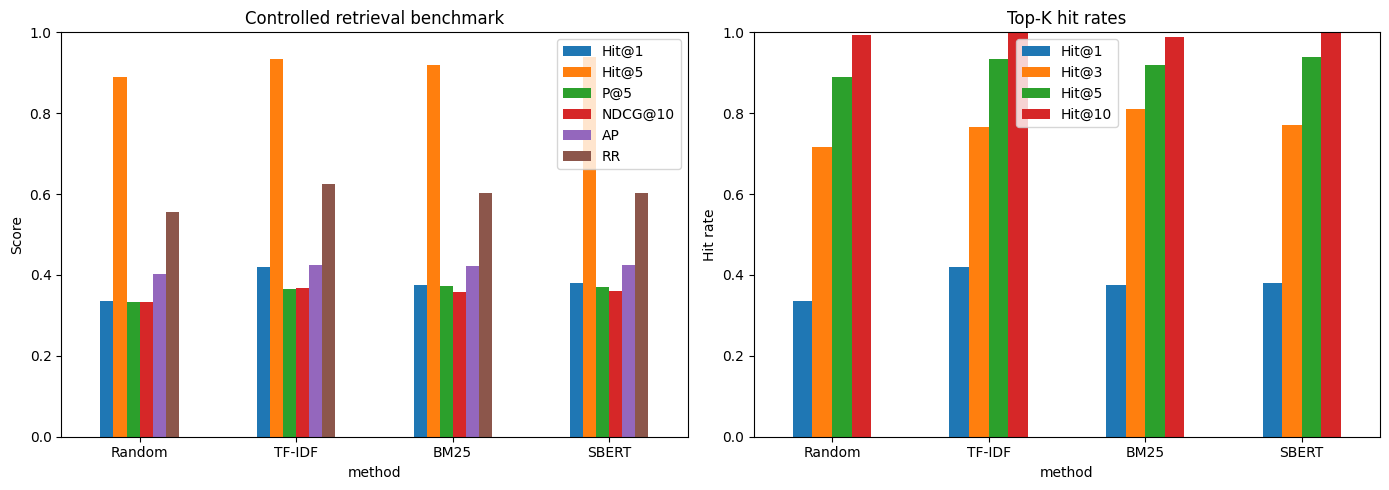

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ["Hit@1", "Hit@5", "P@5", "NDCG@10", "AP", "RR"]
plot_data = controlled_summary_with_random.set_index("method")[metrics]

plot_data.plot(kind="bar", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Controlled retrieval benchmark")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=0)

rank_data = controlled_summary_with_random.set_index("method")[
    ["Hit@1", "Hit@3", "Hit@5", "Hit@10"]
]
rank_data.plot(kind="bar", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Top-K hit rates")
axes[1].set_ylabel("Hit rate")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=180)
plt.show()


## 13. Export all research outputs

The workbook preserves both the original evaluation and the new controlled benchmark.

### Sheets

- `gold_prevalence`
- `label_weights`
- `benchmark_pairs`
- `query_sampling`
- `benchmark_composition`
- `controlled_summary`
- `random_summary`
- `statistical_tests`
- `hard_negative_diagnostics`
- `benchmark_sensitivity`

This makes the benchmark auditable and reproducible.


In [15]:
benchmark_composition_df = (
    benchmark_df.groupby("category")
    .agg(
        n_pairs=("candidate_index", "size"),
        mean_jaccard=("jaccard", "mean"),
        mean_weighted_jaccard=("weighted_jaccard", "mean"),
        mean_rare_jaccard=("rare_jaccard", "mean")
    )
    .reset_index()
)

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    prevalence_df.to_excel(writer, sheet_name="gold_prevalence", index=False)
    weight_df.to_excel(writer, sheet_name="label_weights", index=False)
    benchmark_df.to_excel(writer, sheet_name="benchmark_pairs", index=False)
    query_sampling_df.to_excel(writer, sheet_name="query_sampling", index=False)
    benchmark_composition_df.to_excel(writer, sheet_name="benchmark_composition", index=False)
    controlled_summary_with_random.to_excel(writer, sheet_name="controlled_summary", index=False)
    random_summary.to_excel(writer, sheet_name="random_summary", index=False)
    stats_df.to_excel(writer, sheet_name="statistical_tests", index=False)
    hard_diag_df.to_excel(writer, sheet_name="hard_negative_diagnostics", index=False)
    benchmark_sensitivity_df.to_excel(writer, sheet_name="benchmark_sensitivity", index=False)

print("Saved:", OUTPUT_XLSX)
print("Saved:", PLOT_PATH)


Saved: retrieval_results_v3.xlsx
Saved: retrieval_v3_benchmark.png


# Recommended thesis reporting

The primary claim should be based on the **controlled hard-negative benchmark**, not on the original all-pairs Jaccard experiment alone.

A defensible reporting structure is:

1. **Weak-label validation:** report V-A/V-B/V-C agreement.
2. **Original retrieval experiment:** report as an ablation/baseline.
3. **Controlled retrieval experiment:** compare Random, TF-IDF, BM25 and SBERT.
4. **Statistical significance:** report paired bootstrap 95% CIs and p-values.
5. **Hard-negative analysis:** demonstrate whether semantic retrieval can separate positives from candidates that share common labels.
6. **Sensitivity analysis:** show that conclusions are not dependent on one arbitrary threshold.

Do not tune the benchmark after seeing SBERT results. If SBERT loses to TF-IDF or BM25, that is a valid research result and should be reported.
